### Approach

* Probability-weighted ensemble of XGBoost and Random Forest models
* Target Encoding the "Driver" feature
* Add new features for Target encoding 3 pairs of features - (Stint, Year), (Compound, Year) and (Race, Year)

In [1]:
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger("util").setLevel(logging.ERROR)

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

## Training Data EDA

In [2]:
print(f"Shape of train DataFrame: {train.shape}")
print("\nInfo about train DataFrame:")
train.info()

Shape of train DataFrame: (439140, 16)

Info about train DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RacePr

### Chi squared and Cramer's V for categorical variables vs PitNextLap

In [3]:
from scipy.stats import chi2_contingency

object_cols = train.select_dtypes(include=['object']).columns

for col in object_cols:

    contingency_table = pd.crosstab(train[col], train['PitNextLap'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\nVariable: {col}")
    print(f"  Chi-squared statistic: {chi2:.4f}")
    print(f"  P-value: {p:.4f}")
    print(f"  Degrees of Freedom: {dof}")

    if p < 0.05:
        print(f"  Conclusion: Reject the null hypothesis. There is a significant association between {col} and PitNextLap.")
    else:
            print(f"  Conclusion: Fail to reject the null hypothesis. There is no significant association between {col} and PitNextLap.")


Variable: Driver
  Chi-squared statistic: 8022.7790
  P-value: 0.0000
  Degrees of Freedom: 886
  Conclusion: Reject the null hypothesis. There is a significant association between Driver and PitNextLap.

Variable: Compound
  Chi-squared statistic: 30866.3179
  P-value: 0.0000
  Degrees of Freedom: 4
  Conclusion: Reject the null hypothesis. There is a significant association between Compound and PitNextLap.

Variable: Race
  Chi-squared statistic: 15545.7637
  P-value: 0.0000
  Degrees of Freedom: 25
  Conclusion: Reject the null hypothesis. There is a significant association between Race and PitNextLap.


Driver, Compound and Race have significant association with target. Let's quantify the strength of the associations using Cramer's V

In [4]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    if min_dim == 0: # Handle cases where one variable has only one unique value
        return 0.0
    return np.sqrt(chi2 / (n * min_dim))

object_cols = train.select_dtypes(include=['object']).columns

for col in object_cols:
    v = cramers_v(train[col], train['PitNextLap'])
    print(f"\nVariable: {col}")
    print(f"  Cramer's V: {v:.4f}")


Variable: Driver
  Cramer's V: 0.1352

Variable: Compound
  Cramer's V: 0.2651

Variable: Race
  Cramer's V: 0.1882


A value between 0.1 and 0.3 is considered to be a "weak association". Out of these 3, Compound has the highest strength in association with pitting in the next lap.

### Average Group Size (AGS) and Cardinality of Categorical Variables

In [5]:
for col in object_cols:
    print(f"Variable '{col}': {train[col].nunique()} unique values")
    print(f"Variable '{col}': {train.shape[0]/train[col].nunique()} Average Group Size")

Variable 'Driver': 887 unique values
Variable 'Driver': 495.0845546786922 Average Group Size
Variable 'Compound': 5 unique values
Variable 'Compound': 87828.0 Average Group Size
Variable 'Race': 26 unique values
Variable 'Race': 16890.0 Average Group Size


In general, variables with a cardinality of 15-1000, and AGS of > 20, ('Driver' and 'Race') are good candidates for Target Encoding.

### Correlation Matrix of Numerical Variables

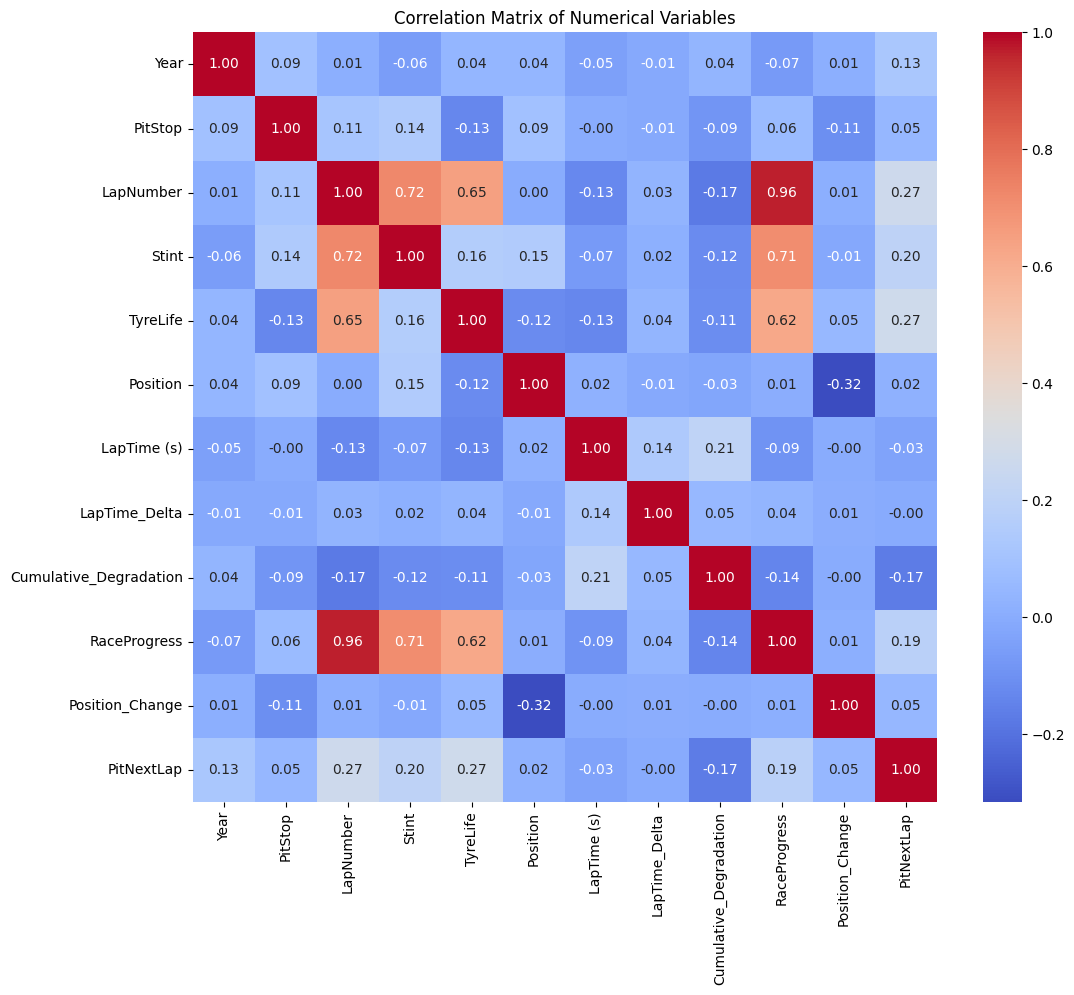

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_matrix = train.select_dtypes(include=['int64', 'float64']).columns.drop('id', errors='ignore')
correlation_matrix = train[numerical_cols_for_matrix].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Position, Laptime and Laptime_Delta have poor correlations with target.

### Feature filtering using Mutual Information

Now, let's calculate the Mututal Information between each variable and the target. This is purely for the purpose of ranking, and does not quantify the strength of association, since it's not normalized.

In [7]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np
from sklearn.preprocessing import LabelEncoder

mis_all = []
le = LabelEncoder()
train_enc = train.copy()

for feature in train.columns:
    if feature not in ['id', 'PitNextLap']:
        discrete = False
        if feature in object_cols:
            discrete = True
            train_enc[feature] = le.fit_transform(train[feature])

        this_mi = mutual_info_classif(pd.DataFrame(train_enc[feature]), train_enc['PitNextLap'], discrete_features=discrete)
        mis_all.append((feature, this_mi))

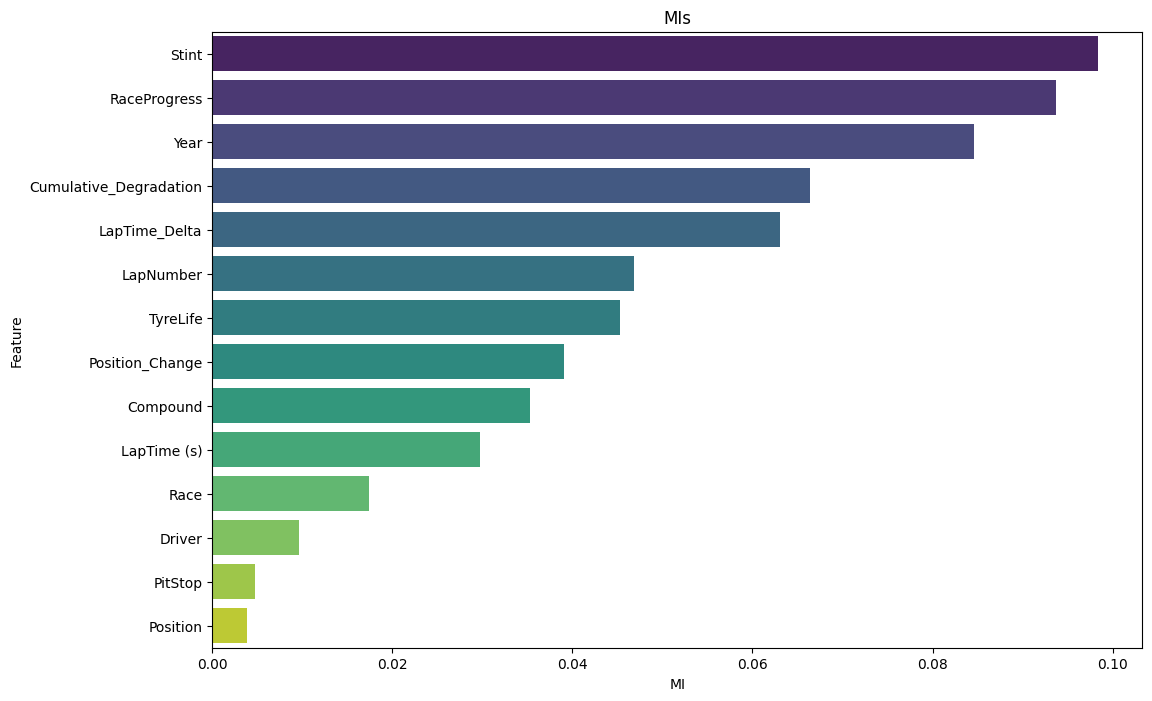

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

mis = [foo[1][0] for foo in mis_all]
features = [foo[0] for foo in mis_all]

mi_df = pd.DataFrame({'Feature': np.array(features), 'MI': np.array(mis)})
mi_df = mi_df.sort_values(by='MI', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='MI', y='Feature', data=mi_df, palette='viridis')
plt.title('MIs')
plt.xlabel('MI')
plt.ylabel('Feature')
plt.show()

Since there is no significant Elbow drop here, we can't drop any features.

### Feature filtering using Permutation Baseline

In [9]:
# from scipy.stats import rankdata
# from sklearn.feature_selection import mutual_info_classif
# import numpy as np
# from scipy.stats import spearmanr, f_oneway

# def permutation_threshold(X, y, discrete, n_permutations=100):
#     X = pd.DataFrame(X)
#     x = X.values.ravel()
    
#     if discrete:
#         real_mi = mutual_info_classif(X, y, discrete_features=True)[0]
        
#         null_mi = np.zeros(n_permutations)
#         for i in range(n_permutations):
#             y_perm = np.random.permutation(y)
#             null_mi[i] = mutual_info_classif(X, y_perm, discrete_features=True)[0]
        
#         real_pct = np.mean(null_mi <= real_mi)
    
#     else:
#         real_mi = mutual_info_classif(X, y, discrete_features=False)[0]
        
#         real_spearman = abs(spearmanr(x, y).statistic)
        
#         null_spearman = np.zeros(n_permutations)
#         for i in range(n_permutations):
#             y_perm = np.random.permutation(y)
#             null_spearman[i] = abs(spearmanr(x, y_perm).statistic)
        
#         real_pct = np.mean(null_spearman <= real_spearman)
    
#     keep = real_pct > 0.95
#     return keep, real_mi, real_pct
    
# mis = []
# le = LabelEncoder()
# train_enc = train.copy()

# for feature in train.columns:
#     print (feature)
#     if feature not in ['id', 'PitNextLap']:
#         discrete = False
#         if feature in object_cols:
#             discrete = True
#             train_enc[feature] = le.fit_transform(train[feature])
        
#         print (permutation_threshold(train_enc[feature], train_enc['PitNextLap'], discrete))

Since Permutation baseline doesn't filter any features either, we'll instead rely on shap values after training.

### Add surface Temperature Data

In [10]:
# race_to_details_map = {
#     'Dutch Grand Prix': {'Month': 'August', 'Country': 'Netherlands'},
#     'Mexico City Grand Prix': {'Month': 'October', 'Country': 'Mexico'},
#     'Pre-Season Testing': {'Month': 'February', 'Country': 'Spain'}, # Assuming Barcelona, Spain for testing
#     'Hungarian Grand Prix': {'Month': 'July', 'Country': 'Hungary'},
#     'Monaco Grand Prix': {'Month': 'May', 'Country': 'France'},
#     'Canadian Grand Prix': {'Month': 'June', 'Country': 'Canada'},
#     'Austrian Grand Prix': {'Month': 'July', 'Country': 'Austria'},
#     'Spanish Grand Prix': {'Month': 'May', 'Country': 'Spain'},
#     'Italian Grand Prix': {'Month': 'September', 'Country': 'Italy'},
#     'Bahrain Grand Prix': {'Month': 'March', 'Country': 'Bahrain'},
#     'Singapore Grand Prix': {'Month': 'September', 'Country': 'Singapore'},
#     'Miami Grand Prix': {'Month': 'May', 'Country': 'United States'},
#     'Australian Grand Prix': {'Month': 'April', 'Country': 'Australia'},
#     'Saudi Arabian Grand Prix': {'Month': 'March', 'Country': 'Saudi Arabia'},
#     'United States Grand Prix': {'Month': 'October', 'Country': 'United States'},
#     'Abu Dhabi Grand Prix': {'Month': 'December', 'Country': 'United Arab Emirates'},
#     'Emilia Romagna Grand Prix': {'Month': 'May', 'Country': 'Italy'},
#     'British Grand Prix': {'Month': 'July', 'Country': 'United Kingdom'},
#     'Qatar Grand Prix': {'Month': 'October', 'Country': 'Qatar'},
#     'Japanese Grand Prix': {'Month': 'October', 'Country': 'Japan'},
#     'Las Vegas Grand Prix': {'Month': 'November', 'Country': 'United States'},
#     'Azerbaijan Grand Prix': {'Month': 'June', 'Country': 'Azerbaijan'},
#     'São Paulo Grand Prix': {'Month': 'November', 'Country': 'Brazil'},
#     'Belgian Grand Prix': {'Month': 'August', 'Country': 'Belgium'},
#     'Chinese Grand Prix': {'Month': 'April', 'Country': 'China'},
#     'French Grand Prix': {'Month': 'July', 'Country': 'France'}
# }

# train['Month'] = train['Race'].map(lambda a: race_to_details_map[a]['Month'])
# test['Month'] = test['Race'].map(lambda a: race_to_details_map[a]['Month'])
# train['Country'] = train['Race'].map(lambda a: race_to_details_map[a]['Country'])
# test['Country'] = test['Race'].map(lambda a: race_to_details_map[a]['Country'])

In [11]:
# weather_data = pd.read_csv('/kaggle/input/datasets/samithsachidanandan/average-monthly-surface-temperature-1940-2024/average-monthly-surface-temperature.csv')
# weather_data['dt'] = pd.to_datetime(weather_data['Day'])
# weather_data['Month'] = weather_data['dt'].dt.strftime('%B')
# weather_data['Year'] = weather_data['dt'].dt.year
# weather_data.rename(columns={"Entity": "Country"}, inplace=True)
# average_temp_by_location_time = weather_data.groupby(['Country', 'Month', 'Year'])['Average surface temperature'].mean().reset_index()

In [12]:
# print (average_temp_by_location_time['Year'].max())
# print (train['Year'].max())

In [13]:
# average_temp_by_location_time.loc[len(average_temp_by_location_time)] = ['Singapore', 'September', 2022, 27.9]
# average_temp_by_location_time.loc[len(average_temp_by_location_time)] = ['Singapore', 'September', 2023, 28.7]
# average_temp_by_location_time.loc[len(average_temp_by_location_time)] = ['Singapore', 'September', 2024, 28.3]

#Use 2024 data for the missing 2025 weather data
# train['Year'] = train['Year'].apply(lambda a: a-1 if a==2025 else a)
# test['Year'] = test['Year'].apply(lambda a: a-1 if a==2025 else a)
# train = pd.merge(train, average_temp_by_location_time, on=['Country', 'Month', 'Year'], how='left')
# test = pd.merge(test, average_temp_by_location_time, on=['Country', 'Month', 'Year'], how='left')

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder
#from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

y = train['PitNextLap'].astype(int)
features = [col for col in train.columns if col not in ['id', 'PitNextLap', 'Country', 'Month', 'Average surface temperature']]
print (features)

X = train[features]

median_stint = {
        "SOFT": 14,
        "MEDIUM": 17,
        "HARD": 23,
        "INTERMEDIATE": 17,
        "WET": 11,
    }

compound_raw = X["Compound"]
X["TyreLife_Normalized"] = (
        X["TyreLife"] / compound_raw.map(median_stint)
    )

categorical_features_ohe_other = ['Compound'] # Only Compound for general OHE
categorical_features_target_other = ['Driver'] # Only Driver for general Target Encoding
features_for_race_encodings = ['Race'] # Race will be both OHE and Target Encoded

preprocessor_lgb = ColumnTransformer(
transformers=[
    ('ohe_compound', OneHotEncoder(handle_unknown='ignore'), categorical_features_ohe_other), # OHE Compound
    ('ohe_race', OneHotEncoder(handle_unknown='ignore'), features_for_race_encodings), # OHE Race        
    ('sorrynotsorry', 'drop', ['Year', 'Driver'])
],
remainder='passthrough' # Keep other numerical features as they are
)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('target_enc_driver', TargetEncoder(random_state=42, smooth=20), categorical_features_target_other), # Target encode Driver
        ('ohe_compound', OneHotEncoder(handle_unknown='ignore'), categorical_features_ohe_other), # OHE Compound
        ('target_enc_race', TargetEncoder(random_state=42, smooth=20), features_for_race_encodings), # Target encode Race
        ('ohe_race', OneHotEncoder(handle_unknown='ignore'), features_for_race_encodings), # OHE Race        
    ],
    remainder='passthrough' # Keep other numerical features as they are
)

['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']


### Feature Engineering

In [15]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class FEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        
        self.prior_prob_race_compound = None
        self.prior_prob_race_year = None
        self.prior_prob_stint_year = None
        self.prior_prob_compound_year = None

    def fit(self, X, y):
        df = X.copy()
        df['PitNextLap'] = y
        self.prior_prob_race_compound = df.groupby(['Race', 'Compound'])['PitNextLap'].mean().reset_index()
        self.prior_prob_race_year = df.groupby(['Race', 'Year'])['PitNextLap'].mean().reset_index()
        self.prior_prob_stint_year = df.groupby(['Stint', 'Year'])['PitNextLap'].mean().reset_index()
        self.prior_prob_compound_year = df.groupby(['Compound', 'Year'])['PitNextLap'].mean().reset_index()
        
        return self

    def transform(self, X):
        X_out = X.copy()
        
        X_out = pd.merge(X_out, self.prior_prob_race_compound, on=['Race', 'Compound'], how='left', suffixes=('', '_prior'))
        X_out = X_out.rename(columns={'PitNextLap_prior': 'Race_Compound_Prior_Prob'})

        X_out = pd.merge(X_out, self.prior_prob_race_year, on=['Race', 'Year'], how='left', suffixes=('', '_prior'))
        X_out = X_out.rename(columns={'PitNextLap_prior': 'Race_Year_Prior_Prob'})

        X_out = pd.merge(X_out, self.prior_prob_stint_year, on=['Stint', 'Year'], how='left', suffixes=('', '_prior'))
        X_out = X_out.rename(columns={'PitNextLap_prior': 'Stint_Year_Prior_Prob'})

        X_out = pd.merge(X_out, self.prior_prob_compound_year, on=['Compound', 'Year'], how='left', suffixes=('', '_prior'))
        X_out = X_out.rename(columns={'PitNextLap_prior': 'Compound_Year_Prior_Prob'})

        return X_out

### XGBoost and RandomForest Hyperparameter Tuning

In [16]:
# import optuna
# from sklearn.metrics import roc_auc_score
# from sklearn.model_selection import cross_validate, StratifiedKFold

# def objective_xgb(trial):
#     # Hyperparameters to tune for XGBoost
#     param = {
#         'objective': 'binary:logistic',
#         'eval_metric': 'logloss',
#         'use_label_encoder': False,
#         'random_state': 42,
#         'n_jobs': -1,
#         'device': 'cuda',
#         'tree_method': 'hist',
#         'scale_pos_weight': (len(y[y == 0]) / len(y[y == 1])),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
#         'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True)
#     }

#     model = Pipeline(steps=[
#         ('preprocessor', preprocessor_xgb),
#         ('classifier', xgb.XGBClassifier(**param))
#     ])

#     pipeline = Pipeline([
#         ('feature_engineering', FEEncoder()),
#         #('ensemble_model', ensemble)
#         ('model', model)
#         ])
    
#     scores = cross_validate(
#         estimator=pipeline,
#         X=X, 
#         y=y, 
#         cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), 
#         scoring='roc_auc'
#     )

#     return scores['test_score'].mean()

# study = optuna.create_study(direction='maximize', study_name='xgb_optimization', load_if_exists=True)
# study.optimize(objective_xgb, n_trials=150, show_progress_bar=True)

# print("Number of finished trials: ", len(study.trials))
# print("Best trial:")
# trial = study.best_trial

# print(f"  Value: {trial.value:.4f}")
# print("  Params: ")
# for key, value in trial.params.items():
#     print(f"    {key}: {value}")

# # n_estimators: 500
# # 2483.4s	225	    learning_rate: 0.05414044697790815
# # 2483.4s	226	    max_depth: 8
# # 2483.4s	227	    subsample: 0.9095630474675961
# # 2483.4s	228	    colsample_bytree: 0.5530946037784168
# # 2483.4s	229	    gamma: 3.352206419195436e-08
# # 2483.4s	230	    lambda: 0.1395888561040328
# # 2483.4s	231	    alpha: 5.2561459162019464e-08

In [17]:
# import optuna
# import lightgbm as lgb
# from sklearn.metrics import roc_auc_score
# from sklearn.pipeline import Pipeline
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTE

# def objective_lgb(trial):
#     # Hyperparameters to tune for LightGBM
#     param = {
#         'objective': 'binary',
#         'metric': 'auc',
#         'boosting_type': 'gbdt',
#         'n_jobs': -1,
#         'device': 'gpu',
#         'max_bin': 63, 
#         'random_state': 42,
#         'is_unbalance': True, # Handles class imbalance, similar to scale_pos_weight
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 100),
#         'max_depth': trial.suggest_int('max_depth', -1, 15),
#         'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#     }

#     # Use ImbPipeline if SMOTE is desired, otherwise a regular Pipeline
#     model = ImbPipeline(steps=[
#         ('preprocessor', preprocessor_lgb),
#         ('classifier', lgb.LGBMClassifier(**param))
#     ])

#     pipeline = Pipeline([
#         ('feature_engineering', FEEncoder()),
#         #('ensemble_model', ensemble)
#         ('model', model)
#         ])
    
#     scores = cross_validate(
#         estimator=pipeline,
#         X=X, 
#         y=y, 
#         cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), 
#         scoring='roc_auc'
#     )

#     return scores['test_score'].mean()

# # Create a study and optimize it for LightGBM
# study_lgb = optuna.create_study(direction='maximize', study_name='lgb_optimization', load_if_exists=True)
# study_lgb.optimize(objective_lgb, n_trials=150, show_progress_bar=True)

# print("Number of finished trials for LightGBM: ", len(study_lgb.trials))
# print("Best trial for LightGBM:")
# trial_lgb = study_lgb.best_trial

# print(f"  Value: {trial_lgb.value:.4f}")
# print("  Params: ")
# for key, value in trial_lgb.params.items():
#     print(f"    {key}: {value}")

# #New
# # n_estimators: 942
# #     learning_rate: 0.06250050427279591
# #     num_leaves: 64
# #     max_depth: 15
# #     min_child_samples: 329
# #     subsample: 0.877650155117543
# #     colsample_bytree: 0.5359982498789053
# #     reg_alpha: 9.897451095580182
# #     reg_lambda: 0.005819723907442821
    
# # n_estimators: 931
# #     learning_rate: 0.05325809257332312
# #     num_leaves: 83
# #     max_depth: 9
# #     min_child_samples: 156
# #     subsample: 0.5820389823067827
# #     colsample_bytree: 0.5198555301603772
# #     reg_alpha: 9.692844859786788
# #     reg_lambda: 3.2948430607114104e-08

### Probability Weighted Ensemble

Now, let's find the optimal way of combining scores from both models, by evaluating on the validation set.

In [18]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold
    
type_exp = 'cvscoring'
# type_exp = 'shap'

# # #Optuna
best_xgb_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    #('smote', SMOTE(random_state=42)),
        ('classifier', xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, 
        random_state=42,
        n_jobs=-1,
        device="cuda",
        tree_method="hist",
        n_estimators= 473,
    learning_rate= 0.06524769046360544,
    max_depth= 8,
    subsample= 0.9363975584489155,
    colsample_bytree= 0.5169040586170885,
    gamma= 0.01925583690489395,
    reg_lambda = 0.4683312228037354,
    alpha= 0.2627044201672802,
        scale_pos_weight=(len(y[y == 0]) / len(y[y == 1]))))])

best_lgb_model = ImbPipeline(steps=[
            ('preprocessor', preprocessor_lgb),
                ('classifier', lgb.LGBMClassifier(
            objective='binary',
            n_estimators=931,      # Equivalent to num_boost_round
            learning_rate=0.045816501438476355,
            num_leaves=88,
            max_depth = 12,
            device="gpu",
            metric="auc",
            is_unbalance=True,
            max_bin=63,
            min_child_samples = 363,
            subsample = 0.8327458044712922,
            colsample_bytree = 0.5000087212001009,
            reg_alpha = 7.043755263678762e-07,
            reg_lambda = 5.754931999350138,
            random_state=42,
            verbose=4             # Suppresses unnecessary logs
        ))])

# best_lgb_model = ImbPipeline(steps=[
#             ('preprocessor', preprocessor),
#                 ('classifier', lgb.LGBMClassifier(
#             n_estimators = 942,
#             learning_rate = 0.06250050427279591,
#             num_leaves = 64,
#             max_depth = 15,
#             min_child_samples = 329,
#             subsample = 0.877650155117543,
#             colsample_bytree = 0.5359982498789053,
#             reg_alpha = 9.897451095580182,
#             reg_lambda = 0.005819723907442821,
#                     device="gpu",
#                     metric="auc",
#                     is_unbalance=True,
#                     max_bin=63,
#                     objective='binary',
#                     random_state=42,
#                     verbose=4             
#                  ))])
    

if type_exp == 'cvscoring':
    
    weights = [(0.25, 0.75)]
    
    for w1, w2 in weights:
    
        ensemble = VotingClassifier(
            estimators=[('xgb', best_xgb_model), ('lgb', best_lgb_model)],#('rf', best_rf_model)],
            voting='soft',       
            weights=[w1, w2]
            )
    
        pipeline_ensemble = Pipeline([
            ('feature_engineering', FEEncoder()),
            ('ensemble_model', ensemble)
            #('model', best_lgb_model)
            ])
    
        pipeline_lgb = Pipeline([
            ('feature_engineering', FEEncoder()),
            #('ensemble_model', ensemble)
            ('model', best_lgb_model)
            ])
    
        pipeline_xgb = Pipeline([
            ('feature_engineering', FEEncoder()),
            #('ensemble_model', ensemble)
            ('model', best_xgb_model)
            ])
    
        scores = cross_validate(
            estimator=pipeline_ensemble,
            X=X,
            y=y,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            return_train_score=True,
            scoring='roc_auc'
        )
        print(f"  ROC Val AUC Ens : {scores['test_score'].mean():.4f}")
        print(f"  ROC Train AUC Ens : {scores['train_score'].mean():.4f}")
            
        # scores = cross_validate(
        #     estimator=pipeline_lgb,
        #     X=X, 
        #     y=y, 
        #     cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), 
        #     return_train_score=True,
        #     scoring='roc_auc'
        # )
    
        # train_scores = scores['train_score']
        # test_scores = scores['test_score']
        
        # print(f"ROC Val AUC LGB:   {test_scores.mean():.4f}")
        # print(f"ROC Train AUC LGB:   {train_scores.mean():.4f}")
        
        # scores = cross_validate(
        #     estimator=pipeline_xgb,
        #     X=X, 
        #     y=y, 
        #     cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), 
        #     return_train_score=True,
        #     scoring='roc_auc'
        # )
    
        # train_scores = scores['train_score']
        # test_scores = scores['test_score']
        
        # print(f"ROC Val AUC XGB:   {test_scores.mean():.4f}")
        # print(f"ROC Train AUC XGB:   {train_scores.mean():.4f}")

        #     scores = cross_validate(
        #     estimator=pipeline_ensemble,
        #     X=X[feats_to_keep], 
        #     y=y, 
        #     cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), 
        #     return_train_score=True,
        #     scoring='roc_auc'
        # )
    
        # train_scores = scores['train_score']
        # test_scores = scores['test_score']
        
        # print(f"ROC Val AUC Ens:   {test_scores.mean():.4f}")
        # print(f"ROC Train AUC Ens:   {train_scores.mean():.4f}")
    
else:
    fe_encoder_global = FEEncoder()
    X_engineered = fe_encoder_global.fit_transform(X.copy(), y.copy()) # Use X, y from data split section
    
    feats_to_remove  = ['Year', 'Race', 'Driver']#, 'PitStop', 'Position']
    features_to_drop = []
    for i in range(len(feats_to_remove)):
        
        #print(f"--- Removing {feature_to_drop} ---")
        feat = feats_to_remove[i]
        
        if feat not in ['Race']:
            features_to_drop = feats_to_remove[:i+1]

        if i<2:
            continue
            
        preprocessor_lgb = ColumnTransformer(
            transformers=[
                ('target_enc_driver', TargetEncoder(random_state=42, smooth=20), categorical_features_target_other), # Target encode Driver
                ('ohe_compound', OneHotEncoder(handle_unknown='ignore'), categorical_features_ohe_other), # OHE Compound
                ('target_enc_race', TargetEncoder(random_state=42, smooth=20), features_for_race_encodings), # Target encode Race
                ('ohe_race', OneHotEncoder(handle_unknown='ignore'), features_for_race_encodings), # OHE Race        
                ('sorrynotsorry', 'drop', features_to_drop)
            ],
            remainder='passthrough' # Keep other numerical features as they are
        )
        
        if feat == 'Race':
            preprocessor_lgb = ColumnTransformer(
            transformers=[
                ('target_enc_driver', TargetEncoder(random_state=42, smooth=20), categorical_features_target_other), # Target encode Driver
                ('ohe_compound', OneHotEncoder(handle_unknown='ignore'), categorical_features_ohe_other), # OHE Compound
                ('ohe_race', OneHotEncoder(handle_unknown='ignore'), features_for_race_encodings), # OHE Race        
                ('sorrynotsorry', 'drop', features_to_drop)
            ],
            remainder='passthrough' # Keep other numerical features as they are
        )

        if feat == 'Driver':
            preprocessor_lgb = ColumnTransformer(
            transformers=[
                ('ohe_compound', OneHotEncoder(handle_unknown='ignore'), categorical_features_ohe_other), # OHE Compound
                ('ohe_race', OneHotEncoder(handle_unknown='ignore'), features_for_race_encodings), # OHE Race        
                ('sorrynotsorry', 'drop', features_to_drop)
            ],
            remainder='passthrough' # Keep other numerical features as they are
        )
        
        #new
        # best_lgb_model = ImbPipeline(steps=[
        #     ('preprocessor', preprocessor_lgb),
        #         ('classifier', lgb.LGBMClassifier(
        #     n_estimators = 942,
        #     learning_rate = 0.06250050427279591,
        #     num_leaves = 64,
        #     max_depth = 15,
        #     min_child_samples = 329,
        #     subsample = 0.877650155117543,
        #     colsample_bytree = 0.5359982498789053,
        #     reg_alpha = 9.897451095580182,
        #     reg_lambda = 0.005819723907442821,
        #             device="gpu",
        #             metric="auc",
        #             is_unbalance=True,
        #             max_bin=63,
        #             objective='binary',
        #             random_state=42,
        #             verbose=4             # Suppresses unnecessary logs
        #          ))])

        #old
        best_lgb_model = ImbPipeline(steps=[
            ('preprocessor', preprocessor_lgb),
                ('classifier', lgb.LGBMClassifier(
            objective='binary',
            n_estimators=931,      # Equivalent to num_boost_round
            learning_rate=0.05325809257332312,
            num_leaves=83,
            max_depth = 9,
            device="gpu",
            metric="auc",
            is_unbalance=True,
            max_bin=63,
            min_child_samples = 156,
            subsample = 0.5820389823067827,
            colsample_bytree = 0.5198555301603772,
            reg_alpha = 9.692844859786788,
            reg_lambda = 3.2948430607114104e-08,
            random_state=42,
            verbose=4             # Suppresses unnecessary logs
        ))])

        ensemble_experiment = VotingClassifier(
        estimators=[('xgb', best_xgb_model), ('lgb', best_lgb_model)],
        voting='soft',
        weights=[0.25, 0.75]
            )
        try:
            scores = cross_validate(
                #estimator=ensemble_experiment,
                estimator=best_lgb_model,
                X=X_engineered, # Use the modified engineered dataset
                y=y,
                cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                return_train_score=True,
                scoring='roc_auc'
            )
            print(f"  ROC Val AUC Ens (w/o {features_to_drop}): {scores['test_score'].mean():.4f}")
            print(f"  ROC Train AUC Ens (w/o {features_to_drop}): {scores['train_score'].mean():.4f}")
        except Exception as e:
            print(f"  Error evaluating without {features_to_drop}: {e}")
            print("\n" + "="*50 + "\n")

[LightGBM] [Info] Number of positive: 58254, number of negative: 234506
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.864085
[LightGBM] [Info] Total Bins 733
[LightGBM] [Info] Number of data points in the train set: 292760, number of used features: 46
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 64 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 16 dense feature groups (4.47 MB) transferred to GPU in 0.004612 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198982 -> initscore=-1.392668
[LightGBM] [Info] Start training from score -1.392668
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 12
[LightGBM] [Debug] Trained a tree with leaves = 88 and depth = 

Since the model performance doesn't change on removing Race TE, Driver and Year, we'll remove these features in the hope of a more general model, before submitting test predictions.

The best AUC value is obtained using these weight values : 0.25 for XGB, and 0.75 for LGBM.

### Submission - train on entire "train.csv" file

In [19]:
# X['PitNextLap'] = y

# prior_prob_stint_year = X.groupby(['Stint', 'Year'])['PitNextLap'].mean().reset_index()
# X = pd.merge(X, prior_prob_stint_year, on=['Stint', 'Year'], how='left', suffixes=('', '_prior'))
# X = X.rename(columns={'PitNextLap_prior': 'Stint_Year_Prior_Prob'})

# prior_prob_compound_year = X.groupby(['Compound', 'Year'])['PitNextLap'].mean().reset_index()
# X = pd.merge(X, prior_prob_compound_year, on=['Compound', 'Year'], how='left', suffixes=('', '_prior'))
# X = X.rename(columns={'PitNextLap_prior': 'Compound_Year_Prior_Prob'})

# prior_prob_race_compound = X.groupby(['Race', 'Compound'])['PitNextLap'].mean().reset_index()
# X = pd.merge(X, prior_prob_race_compound, on=['Race', 'Compound'], how='left', suffixes=('', '_prior'))
# X = X.rename(columns={'PitNextLap_prior': 'Race_Compound_Prior_Prob'})

# prior_prob_race_year = X.groupby(['Race', 'Year'])['PitNextLap'].mean().reset_index()
# X = pd.merge(X, prior_prob_race_year, on=['Race', 'Year'], how='left', suffixes=('', '_prior'))
# X = X.rename(columns={'PitNextLap_prior': 'Race_Year_Prior_Prob'})

# X.drop(columns=['PitNextLap'], inplace=True)

# compound_raw = test["Compound"]
# test["TyreLife_Normalized"] = (
#         test["TyreLife"] / compound_raw.map(median_stint)
#     )

# test = pd.merge(test, prior_prob_stint_year, on=['Stint', 'Year'], how='left', suffixes=('', '_prior'))
# test = test.rename(columns={'PitNextLap': 'Stint_Year_Prior_Prob'})

# test = pd.merge(test, prior_prob_compound_year, on=['Compound', 'Year'], how='left', suffixes=('', '_prior'))
# test = test.rename(columns={'PitNextLap': 'Compound_Year_Prior_Prob'})

# test = pd.merge(test, prior_prob_race_compound, on=['Race', 'Compound'], how='left', suffixes=('', '_prior'))
# test = test.rename(columns={'PitNextLap': 'Race_Compound_Prior_Prob'})

# test = pd.merge(test, prior_prob_race_year, on=['Race', 'Year'], how='left', suffixes=('', '_prior'))
# test = test.rename(columns={'PitNextLap': 'Race_Year_Prior_Prob'})

# #print (X.columns)

# best_xgb_model.fit(X, y)
# best_lgb_model.fit(X, y)

In [20]:
# X_test_final = test[features + ['TyreLife_Normalized' , 'Stint_Year_Prior_Prob' , 'Compound_Year_Prior_Prob' , 'Race_Compound_Prior_Prob', 'Race_Year_Prior_Prob']] # Use the same features as the training data

# # Generate probability predictions for the positive class (class 1) on the test data
# print("Generating predictions for the test set...")
# test_probabilities_xgb = best_xgb_model.predict_proba(X_test_final)[:, 1]
# test_probabilities_lgb = best_lgb_model.predict_proba(X_test_final)[:, 1]
# print("Predictions generated.")

# w1 = 0.25
# w2 = 0.75
# ensemble_proba = w1*test_probabilities_xgb + w2*test_probabilities_lgb

# # Create a submission DataFrame
# submission = pd.DataFrame({
#     'id': test['id'],
#     'PitNextLap': ensemble_proba
# })

# print("Submission DataFrame head:")
# display(submission.head())

# # Save the submission DataFrame to a CSV file
# submission.to_csv('submission.csv', index=False)

# print (len(submission))

### Shap Value Analysis for LGBM

In [21]:
# import shap
# import pandas as pd

# lgbm_classifier = best_lgb_model.named_steps['classifier']
# preprocessor_trained = best_lgb_model.named_steps['preprocessor']
# X_processed = preprocessor_trained.transform(X)

# feature_names = preprocessor_trained.get_feature_names_out(input_features=X.columns)
# X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

# # To speed up SHAP calculation, sample a subset of the data
# sampled_X_processed_df = X_processed_df.sample(n=5000, random_state=42) # Sample 5000 instances

# explainer = shap.TreeExplainer(lgbm_classifier)

# # For binary classification, TreeExplainer often returns a single 2D array for the positive class,
# # or a list of two 2D arrays. Let's assume it returns a single 2D array directly.
# shap_values = explainer.shap_values(sampled_X_processed_df)

# # Plot the SHAP summary plot (for the positive class)
# # If shap_values is a list of two arrays, use shap_values[1]
# # If shap_values is a single 2D array, use shap_values directly
# shap.summary_plot(shap_values, sampled_X_processed_df, plot_type="bar")
# shap.summary_plot(shap_values, sampled_X_processed_df)

Let's remove the following features, one by one and see the performance:

* Year
* Target Encoded Race
* TE Driver
* Pitstop
* Position

### Shap Value Analysis for XGB

In [22]:
# import shap
# import pandas as pd

# xgb_classifier = best_xgb_model.named_steps['classifier']
# preprocessor_trained = best_xgb_model.named_steps['preprocessor']
# X_processed = preprocessor_trained.transform(X)

# feature_names = preprocessor_trained.get_feature_names_out(input_features=X.columns)
# X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

# # To speed up SHAP calculation, sample a subset of the data
# sampled_X_processed_df = X_processed_df.sample(n=5000, random_state=42) # Sample 5000 instances

# explainer = shap.TreeExplainer(xgb_classifier)

# shap_values = explainer.shap_values(sampled_X_processed_df)

# shap.summary_plot(shap_values, sampled_X_processed_df, plot_type="bar")
# shap.summary_plot(shap_values, sampled_X_processed_df)

Thanks for reading! Let me know where I can improve things. I have the following steps in mind:

* Log-transform numerical features with a long tail
* Optimize the target encoding smoothing parameter 
* Add a neural network to the ensemble